In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
price =pd.read_csv("C:/Users/user/Desktop/pizza_sales/price_history.csv" , parse_dates = ['effective_date']).sort_values('effective_date')
transaction = pd.read_csv("C:/Users/user/Desktop/pizza_sales/transactions.csv" , parse_dates =['order_date']).sort_values('order_date')

In [3]:
n = transaction.pizza_id
bin = [1,4,6,8,10]
pd.cut(n ,bin).value_counts()

pizza_id
(6, 8]     1823
(1, 4]     1718
(8, 10]    1498
(4, 6]     1219
Name: count, dtype: int64

In [4]:
pd.qcut(n , [0,0.2 , .4 ,.6 , .8 , 1]).value_counts().sort_values(ascending = True)

pizza_id
(9.0, 10.0]      771
(3.0, 5.0]      1041
(5.0, 7.0]      1600
(7.0, 9.0]      1693
(0.999, 3.0]    2059
Name: count, dtype: int64

$ \textit{Outlier\ Detection} $

In [5]:
transaction
transaction.order_date = transaction.order_date.sort_values()

In [6]:
price.head()
price.effective_date = price.effective_date.sort_values()

In [7]:
combined = pd.merge_asof(transaction , price , left_on ='order_date' , right_on = 'effective_date' , by ='pizza_id' )

In [8]:
combined.head()

,order_detail_id,order_id,order_date,pizza_id,quantity,effective_date,price
0,1,1,2026-01-01,4,1,2026-01-01,16.50
1,94,43,2026-01-01,8,1,2026-01-01,20.25
2,95,44,2026-01-01,5,1,2026-01-01,20.25
3,96,45,2026-01-01,2,1,2026-01-01,17.95
4,97,45,2026-01-01,4,1,2026-01-01,16.50


In [9]:
combined   =combined.assign(Total_Value = lambda x: x.quantity * x.price )

In [10]:
combined

,order_detail_id,order_id,order_date,pizza_id,quantity,effective_date,price,Total_Value
0,1,1,2026-01-01,4,1,2026-01-01,16.50,16.50
1,94,43,2026-01-01,8,1,2026-01-01,20.25,20.25
2,95,44,2026-01-01,5,1,2026-01-01,20.25,20.25
3,96,45,2026-01-01,2,1,2026-01-01,17.95,17.95
4,97,45,2026-01-01,4,1,2026-01-01,16.50,16.50
...,...,...,...,...,...,...,...,...
7159,7068,3490,2026-02-28,6,1,2026-02-16,20.50,20.50
7160,7067,3490,2026-02-28,1,1,2026-01-01,20.75,20.75
7161,7066,3489,2026-02-28,1,1,2026-01-01,20.75,20.75
7162,7080,3495,2026-02-28,2,1,2026-02-02,18.50,18.50


In [14]:
combined.columns = combined.columns.str.capitalize()

In [15]:
combined.head()

,Order_detail_id,Order_id,Order_date,Pizza_id,Quantity,Effective_date,Price,Total_value
0,1,1,2026-01-01,4,1,2026-01-01,16.50,16.50
1,94,43,2026-01-01,8,1,2026-01-01,20.25,20.25
2,95,44,2026-01-01,5,1,2026-01-01,20.25,20.25
3,96,45,2026-01-01,2,1,2026-01-01,17.95,17.95
4,97,45,2026-01-01,4,1,2026-01-01,16.50,16.50


In [17]:
combined.describe()

,Order_detail_id,Order_id,Order_date,Pizza_id,Quantity,Effective_date,Price,Total_value
count,7164.000000,7164.000000,7164,7164.000000,7164.000000,7164,7164.000000,7164.000000
mean,3582.500000,1781.173506,2026-01-30 01:50:21.105527,5.713149,1.143635,2026-01-12 21:30:51.256281,19.657712,22.493628
min,1.000000,1.000000,2026-01-01 00:00:00,1.000000,1.000000,2026-01-01 00:00:00,15.250000,15.250000
25%,1791.750000,898.750000,2026-01-15 00:00:00,3.000000,1.000000,2026-01-01 00:00:00,18.500000,18.500000
50%,3582.500000,1796.000000,2026-01-31 00:00:00,6.000000,1.000000,2026-01-01 00:00:00,20.500000,20.750000
75%,5373.250000,2675.250000,2026-02-14 00:00:00,8.000000,1.000000,2026-02-02 00:00:00,20.750000,20.750000
max,7164.000000,3530.000000,2026-02-28 00:00:00,10.000000,6.000000,2026-02-16 00:00:00,21.000000,124.500000
std,2068.212997,1026.562317,NaN,2.950840,0.430772,NaN,1.584756,8.763132


In [19]:
combined.isna().sum()

Order_detail_id    0
Order_id           0
Order_date         0
Pizza_id           0
Quantity           0
Effective_date     0
Price              0
Total_value        0
dtype: int64

In [20]:
combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 7164 entries, 0 to 7163
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_detail_id  7164 non-null   int64         
 1   Order_id         7164 non-null   int64         
 2   Order_date       7164 non-null   datetime64[us]
 3   Pizza_id         7164 non-null   int64         
 4   Quantity         7164 non-null   int64         
 5   Effective_date   7164 non-null   datetime64[us]
 6   Price            7164 non-null   float64       
 7   Total_value      7164 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(4)
memory usage: 447.9 KB


$$\textbf{Clearning Data}$$

In [12]:
mydata = pd.read_csv('C:/Users/user/Desktop/MyMasterPiece/marketing_campaign_data_messy (2).csv')
mydata.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [13]:
print(mydata.columns.tolist())

mydata.columns = mydata.columns.str.strip().str.lower().str.replace(' ' , '_')

[' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks', 'Campaign_Tag']


In [16]:
dollar_sign = mydata['spend'].astype(str).str.contains(r'\$')
print(mydata.loc[dollar_sign , ['campaign_id' , 'spend']].head(5))

   campaign_id     spend
0    CMP-00001   $102.82
21   CMP-00022   $2428.4
22   CMP-00023  $4726.22
31   CMP-00032  $2759.35
32   CMP-00033  $2393.02


In [22]:
mydata['spend'] = mydata['spend'].astype(str).str.replace(r'[^\d.-]','',regex=True)
mydata['spend'] = pd.to_numeric(mydata['spend'])
print('Fixed')
print(mydata.loc[dollar_sign , ['campaign_id' , 'spend']].head(5))

Fixed
   campaign_id    spend
0    CMP-00001   102.82
21   CMP-00022  2428.40
22   CMP-00023  4726.22
31   CMP-00032  2759.35
32   CMP-00033  2393.02


$\textit{Fix\ Missmatched\ Letters}$

In [24]:
print(mydata.channel.unique())

cleanup_map = {'Facebok':'Facebook' , 
               'Tik_Tok':'TikTok' , 
               'E-mail':'Email',
               'Insta_gram':'Instagram',
               'Gogle':'Google Ads',
               'nan':np.nan}
mydata.channel = mydata.channel.replace(cleanup_map)
print('Fixed')
print(mydata.channel.unique())

<StringArray>
[    'TikTok',   'Facebook',      'Email',  'Instagram', 'Google Ads',
     'E-mail',          nan,      'Gogle',    'Tik_Tok',    'Facebok',
 'Insta_gram']
Length: 11, dtype: str
Fixed
<StringArray>
['TikTok', 'Facebook', 'Email', 'Instagram', 'Google Ads', nan]
Length: 6, dtype: str


$\textit{Fix Boolean Missmatch}$

In [26]:
print(mydata.active.unique())

bool_map = {'Y':'True',
            '0':'False',
            'No':'False',
            'Yes':'True',
            '1':'True'}

mydata.active = mydata.active.map(bool_map).fillna(False).astype(bool)
print('Fixed')
print(mydata.active.unique())

<StringArray>
['Y', '0', 'No', 'True', 'Yes', '1', 'False']
Length: 7, dtype: str
Fixed
[ True False]


In [28]:
mydata.head(5)

,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,clicks,campaign_tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,102.82,20.0,True,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,True,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,True,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,False,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,True,NaN,FA


In [29]:
print(mydata.start_date.dtype)

mydata.start_date = pd.to_datetime(mydata.start_date , errors='coerce')
mydata.end_date = pd.to_datetime(mydata.end_date, dayfirst=True , errors='coerce')

print('Fix Applied')
print(mydata.start_date.dtype)



str
Fix Applied
datetime64[us]


C:\Users\user\AppData\Local\Temp\ipykernel_6068\4187012659.py:4: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  mydata.end_date = pd.to_datetime(mydata.end_date, dayfirst=True , errors='coerce')


In [31]:
mydata=  mydata.loc[: , ~mydata.columns.duplicated()]

In [38]:
time_travel = mydata['end_date']<mydata['start_date']
print(mydata.loc[time_travel , ['campaign_id' , 'start_date' , 'end_date']].head(3))

   campaign_id start_date   end_date
23   CMP-00024 2023-05-06 2023-05-01
54   CMP-00055 2023-09-01 2023-08-27
71   CMP-00072 2023-02-01 2023-01-27


In [40]:
mydata.loc[time_travel , 'end_date']  = mydata.loc[time_travel , 'start_date']+ pd.Timedelta(days=30)
print(mydata.loc[time_travel , ['campaign_id' , 'start_date' , 'end_date']].head(3))

   campaign_id start_date   end_date
23   CMP-00024 2023-05-06 2023-06-05
54   CMP-00055 2023-09-01 2023-10-01
71   CMP-00072 2023-02-01 2023-03-03


In [43]:
Q1 = mydata['spend'].quantile(.25)
Q3 = mydata['spend'].quantile(.75)

IQR = Q3 - Q1
Upper_limit = Q3 + (3 * IQR)

outlier_mask = mydata['spend'] > Upper_limit

print(mydata.loc[outlier_mask , ['campaign_id' , 'spend']].head())

mydata.loc[outlier_mask , 'spend'] = Upper_limit
print('Fixed')
print(mydata.loc[outlier_mask , ['campaign_id' , 'spend']].head())

     campaign_id      spend
789    CMP-00790  500000.00
1443   CMP-01444    8921.51
1460   CMP-01461  500000.00
1718   CMP-01719  500000.00
1754   CMP-01755  500000.00
Fixed
     campaign_id      spend
789    CMP-00790  8603.5375
1443   CMP-01444  8603.5375
1460   CMP-01461  8603.5375
1718   CMP-01719  8603.5375
1754   CMP-01755  8603.5375


In [48]:
print(mydata['campaign_name'])

mydata['Season'] = mydata.campaign_name.str.extract(r'Q\d_([^_]+)_')
mydata.head()

0            Q4_Summer_CMP-00001
1            Q1_Launch_CMP-00002
2            Q3_Winter_CMP-00003
3       Q1_BlackFriday_CMP-00004
4            Q2_Winter_CMP-00005
                  ...           
2015         Q3_Summer_CMP-00400
2016         Q4_Summer_CMP-01255
2017         Q2_Launch_CMP-01050
2018         Q4_Winter_CMP-01118
2019         Q4_Launch_CMP-01554
Name: campaign_name, Length: 2020, dtype: str


,campaign_id,campaign_name,start_date,end_date,channel,impressions,clicks,spend,conversions,active,campaign_tag,Season
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI,Summer
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,True,FA,Launch
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,True,EM,Winter
3,CMP-00004,Q1_BlackFriday_CMP-00004,NaT,2023-11-03,TikTok,55886,2019,2180.38,135.0,False,TI,BlackFriday
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA,Winter


In [116]:
fifa_data = pd.read_csv("C:/Users/user/Desktop/Machine Learning Full/archive (1)/FIFA18_official_data.csv")
fifa_data.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Release Clause
0,176580,L. Suárez,30,https://cdn.sofifa.com/players/176/580/18_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,CF,88.0,€198.9M
1,178518,R. Nainggolan,29,https://cdn.sofifa.com/players/178/518/18_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,86.0,88.0,11.0,11.0,14.0,8.0,11.0,CDM,84.0,€72.3M
2,203551,A. Florenzi,26,https://cdn.sofifa.com/players/203/551/18_60.png,Italy,https://cdn.sofifa.com/flags/it.png,82,83,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,79.0,78.0,9.0,8.0,10.0,11.0,10.0,CF,81.0,€37.3M
3,197445,D. Alaba,25,https://cdn.sofifa.com/players/197/445/18_60.png,Austria,https://cdn.sofifa.com/flags/at.png,85,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,82.0,80.0,5.0,7.0,14.0,15.0,9.0,LB,82.0,€66.4M
4,195864,P. Pogba,24,https://cdn.sofifa.com/players/195/864/18_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,92,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,70.0,68.0,5.0,6.0,2.0,4.0,3.0,CM,85.0,€146.3M


In [117]:
fifa_data.iloc[:10 , 5:]

,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Release Clause
0,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,€97M,€500K,2321,Right,5.0,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,CF,88.0,€198.9M
1,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,€42.5M,€130K,2286,Right,3.0,...,86.0,88.0,11.0,11.0,14.0,8.0,11.0,CDM,84.0,€72.3M
2,https://cdn.sofifa.com/flags/it.png,82,83,Roma,https://cdn.sofifa.com/teams/52/light_30.png,€21M,€70K,2267,Right,3.0,...,79.0,78.0,9.0,8.0,10.0,11.0,10.0,CF,81.0,€37.3M
3,https://cdn.sofifa.com/flags/at.png,85,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,€38.5M,€130K,2263,Left,4.0,...,82.0,80.0,5.0,7.0,14.0,15.0,9.0,LB,82.0,€66.4M
4,https://cdn.sofifa.com/flags/fr.png,88,92,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,€76M,€250K,2262,Right,4.0,...,70.0,68.0,5.0,6.0,2.0,4.0,3.0,CM,85.0,€146.3M
5,https://cdn.sofifa.com/flags/gb-wls.png,88,88,Real Madrid,https://cdn.sofifa.com/teams/243/light_30.png,€62M,€375K,2260,Left,4.0,...,55.0,52.0,15.0,15.0,11.0,5.0,6.0,ST,87.0,€127.1M
6,https://cdn.sofifa.com/flags/cl.png,86,86,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,€33M,€160K,2253,Right,4.0,...,89.0,86.0,4.0,2.0,4.0,2.0,4.0,CDM,84.0,€54.5M
7,https://cdn.sofifa.com/flags/be.png,91,92,Manchester City,https://cdn.sofifa.com/teams/10/light_30.png,€104.5M,€400K,2234,Right,4.0,...,58.0,51.0,15.0,13.0,5.0,10.0,13.0,CAM,88.0,€201.2M
8,https://cdn.sofifa.com/flags/es.png,87,87,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,€40M,€250K,2231,Left,3.0,...,84.0,84.0,13.0,15.0,13.0,6.0,13.0,LWB,85.0,€82M
9,https://cdn.sofifa.com/flags/rs.png,81,81,Roma,https://cdn.sofifa.com/teams/52/light_30.png,€11.5M,€70K,2231,Left,2.0,...,82.0,81.0,16.0,15.0,8.0,16.0,6.0,LB,81.0,€19.6M


In [118]:
print(fifa_data.columns.tolist())

fifa_data.columns = fifa_data.columns.str.replace(' ' , '_').str.capitalize()

print('Fixed Columns')
print(fifa_data.columns.tolist())


['ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special', 'Preferred Foot', 'International Reputation', 'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until', 'Height', 'Weight', 'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Best Position', 'Best Overall Rating', 'Release Clause']
Fixed Columns
['Id', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall', 'Potential', 'Club', 'Club_logo', 'Value', 'Wage', 'Special', 'P

In [119]:
fifa_data[fifa_data.Value.astype(str).str.contains(r'[\€]')].loc[:10 , ['Value' , 'Wage']]

,Value,Wage
0,€97M,€500K
1,€42.5M,€130K
2,€21M,€70K
3,€38.5M,€130K
4,€76M,€250K
5,€62M,€375K
6,€33M,€160K
7,€104.5M,€400K
8,€40M,€250K
9,€11.5M,€70K


In [120]:
fifa_data[fifa_data.Value.astype(str).str.contains('M')].loc[:10 , ['Value' , 'Wage']]

,Value,Wage
0,€97M,€500K
1,€42.5M,€130K
2,€21M,€70K
3,€38.5M,€130K
4,€76M,€250K
5,€62M,€375K
6,€33M,€160K
7,€104.5M,€400K
8,€40M,€250K
9,€11.5M,€70K


In [121]:
fifa_data[['Number' , 'Suffix']] = fifa_data.Value.str.extract(r'€?([\d\.]+)([MK]?)')
fifa_data[['Number' , 'Suffix']]

,Number,Suffix
0,97,M
1,42.5,M
2,21,M
3,38.5,M
4,76,M
...,...,...
17922,60,K
17923,50,K
17924,50,K
17925,70,K


In [122]:
multiplier = {'M': 1000000 , 
              'K': 1000}

fifa_data['Numeric_Value']  = fifa_data['Number'].astype(float)*fifa_data['Suffix'].map(multiplier)
fifa_data[['Number' , 'Suffix','Numeric_Value']]


,Number,Suffix,Numeric_Value
0,97,M,97000000.0
1,42.5,M,42500000.0
2,21,M,21000000.0
3,38.5,M,38500000.0
4,76,M,76000000.0
...,...,...,...
17922,60,K,60000.0
17923,50,K,50000.0
17924,50,K,50000.0
17925,70,K,70000.0


In [123]:
fifa_data[['Number_thous' , 'Suffix_thous']] = fifa_data.Wage.str.extract(r'€?([\d\.]+)([MK]?)')
fifa_data[['Number_thous' , 'Suffix_thous']]

,Number_thous,Suffix_thous
0,500,K
1,130,K
2,70,K
3,130,K
4,250,K
...,...,...
17922,500,
17923,500,
17924,500,
17925,1,K


In [124]:
wage_mapper = {'K': 1000}

fifa_data['Wage_Value'] = fifa_data['Number_thous'].astype(float)*fifa_data['Suffix_thous'].map(wage_mapper).fillna(0)

fifa_data[['Number_thous' , 'Suffix_thous' , 'Wage_Value']]


,Number_thous,Suffix_thous,Wage_Value
0,500,K,500000.0
1,130,K,130000.0
2,70,K,70000.0
3,130,K,130000.0
4,250,K,250000.0
...,...,...,...
17922,500,,0.0
17923,500,,0.0
17924,500,,0.0
17925,1,K,1000.0


In [125]:
fifa_data.drop(columns={'Number_thous' , 'Suffix_thous','Number' , 'Suffix'}  , inplace=True)

In [126]:
fifa_data[['Clause_Number' , 'Clause_Suf']] = fifa_data.Release_clause.str.extract(r'€?([\d\.]+)([MK]?)')
fifa_data[['Clause_Number' , 'Clause_Suf']]

,Clause_Number,Clause_Suf
0,198.9,M
1,72.3,M
2,37.3,M
3,66.4,M
4,146.3,M
...,...,...
17922,146,K
17923,119,K
17924,111,K
17925,102,K


In [127]:
clause_map = {'M': 1000000,
              'K': 1000}

fifa_data['Release_clause_Value']=  fifa_data['Clause_Number'].astype(float) * fifa_data['Clause_Suf'].map(clause_map).fillna(0)
fifa_data.Release_clause_Value

0        198900000.0
1         72300000.0
2         37300000.0
3         66400000.0
4        146300000.0
            ...     
17922       146000.0
17923       119000.0
17924       111000.0
17925       102000.0
17926       119000.0
Name: Release_clause_Value, Length: 17927, dtype: float64

In [128]:
fifa_data.drop(columns={'Clause_Number', 'Clause_Suf'} , inplace=True)

In [129]:
print(fifa_data.columns.tolist())

['Id', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall', 'Potential', 'Club', 'Club_logo', 'Value', 'Wage', 'Special', 'Preferred_foot', 'International_reputation', 'Weak_foot', 'Skill_moves', 'Work_rate', 'Body_type', 'Real_face', 'Position', 'Jersey_number', 'Joined', 'Loaned_from', 'Contract_valid_until', 'Height', 'Weight', 'Crossing', 'Finishing', 'Headingaccuracy', 'Shortpassing', 'Volleys', 'Dribbling', 'Curve', 'Fkaccuracy', 'Longpassing', 'Ballcontrol', 'Acceleration', 'Sprintspeed', 'Agility', 'Reactions', 'Balance', 'Shotpower', 'Jumping', 'Stamina', 'Strength', 'Longshots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking', 'Standingtackle', 'Slidingtackle', 'Gkdiving', 'Gkhandling', 'Gkkicking', 'Gkpositioning', 'Gkreflexes', 'Best_position', 'Best_overall_rating', 'Release_clause', 'Numeric_Value', 'Wage_Value', 'Release_clause_Value']


In [133]:
import seaborn as sns


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



C:\Users\user\AppData\Local\Temp\ipykernel_6068\2897569384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = release_table , y = 'Name' , x = 'Release_Clause' , palette='Blues_r' )


Text(0.5, 1.0, 'Player With Highest Release Clause in 2018')

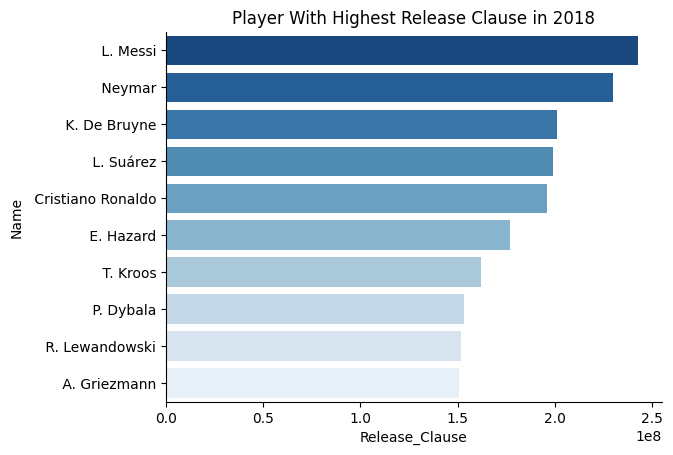

In [138]:
filtered_data = fifa_data[['Name', 'Age','Nationality','Overall','Club','Value', 'Wage','Numeric_Value', 'Wage_Value', 'Release_clause_Value']]
release_table = fifa_data.groupby('Name')['Release_clause_Value'].max().sort_values(ascending=False).head(10).reset_index(name='Release_Clause')
sns.barplot(data = release_table , y = 'Name' , x = 'Release_Clause' , palette='Blues_r' )
sns.despine()
plt.title('Player With Highest Release Clause in 2018')

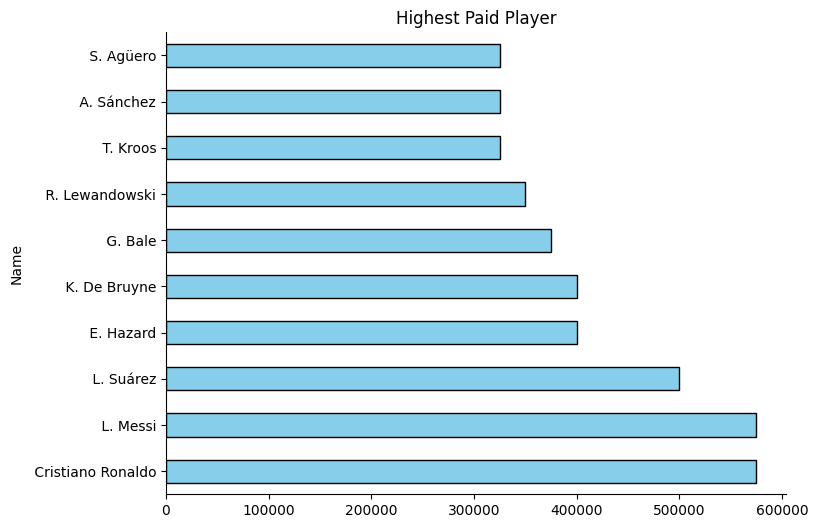

In [149]:
fifa_data.groupby('Name')['Wage_Value'].max().sort_values(ascending=False).head(10).plot(kind = 'barh'  , title='Highest Paid Player',
                                                                                         figsize=(8 , 6) , 
                                                                                         color = 'skyblue' , 
                                                                                         edgecolor = 'black'
                                                                                       )
sns.despine()

